# 08 - PC Service and Conference Overlap

This notebook answers a simple data question:

**Do the same researchers appear repeatedly in the PC member lists?**

I separate two related quantities:

- repeated PC service across conference year rows;
- overlap across different conference PC lists.

The input is the PC member from notebook 06.


## 1 - Setup

In [4]:
from itertools import combinations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager


In [5]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "project_setup.py").exists() and (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError(
        "Could not find the repository root. Launch Jupyter from the repo root "
        "or set PYTHONPATH to the folder containing project_setup.py."
    )

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from project_setup import setup_project

setup = setup_project()
project_folder = setup.project_folder
PROJECT = project_folder
repo = project_folder
config_path = setup.config_path
project_config = setup.project_config

run_mode = setup.run_mode
inputs_config = setup.inputs
outputs_config = setup.outputs
openalex_config = setup.openalex

allow_network = setup.allow_network
use_existing_data = setup.use_existing_data
overwrite_data = setup.overwrite_data
overwrite_artifacts = setup.overwrite_artifacts
openalex_sample_limit = setup.openalex_sample_limit
openalex_sample_include_work_ids = setup.openalex_sample_include_work_ids

step_1_data_dir = project_folder / "step_1_data"
step_1_artifacts_dir = project_folder / "step_1_artifacts"
prepared_dir = step_1_data_dir / "prepared"
intermediate_dir = step_1_data_dir / "intermediate"
summary_tables_dir = step_1_artifacts_dir / "summary_tables"
dependency_tables_dir = step_1_artifacts_dir / "dependency_tables"
check_tables_dir = step_1_artifacts_dir / "check_tables"
images_dir = step_1_artifacts_dir / "figures"

intermediate_dir.mkdir(parents=True, exist_ok=True)
prepared_dir.mkdir(parents=True, exist_ok=True)
summary_tables_dir.mkdir(parents=True, exist_ok=True)
dependency_tables_dir.mkdir(parents=True, exist_ok=True)
check_tables_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

print(project_folder)
print(f"Run mode: {run_mode}")


/Users/endersari/2026-02-citations-vs-pc-memberships
Run mode: fast


In [6]:
font_path = project_folder / "fonts" / "LinLibertine_R.ttf"
font_prop = font_manager.FontProperties(fname=font_path)

mpl.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": font_prop.get_name(),
    "text.usetex": True,
})

CONFERENCES = ["ICFP", "POPL", "OOPSLA", "PLDI"]

COLORS = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "PLDI": "#e5c890",
}

GREY = "#b8b8b8"
EDGE = "#4a4a4a"
GRID = "#dddddd"


## 2 - Load Data

In [7]:
pc = pd.read_parquet(prepared_dir / "pc_members.parquet")

required = [
    "service_key", "conference", "year", "researcher_id", "name",
    "role", "committee_source", "is_visible_pc",
]
missing = sorted(set(required) - set(pc.columns))
if missing:
    raise ValueError(f"Missing columns: {missing}")

pc = pc[required].copy()
pc["conference"] = pd.Categorical(pc["conference"], CONFERENCES, ordered=True)
pc = pc.sort_values(["conference", "year", "name"]).reset_index(drop=True)

print(pc.shape)
display(pc.head())


(2180, 8)


,service_key,conference,year,researcher_id,name,role,committee_source,is_visible_pc
0,ICFP_2017_adamchlipala,ICFP,2017,adamchlipala,Adam Chlipala,PC Member,visible_pc_page,True
1,ICFP_2017_alanjeffrey1,ICFP,2017,alanjeffrey1,Alan Jeffrey,PC Member,visible_pc_page,True
2,ICFP_2017_alexandrasilva,ICFP,2017,alexandrasilva,Alexandra Silva,PC Member,visible_pc_page,True
3,ICFP_2017_benlippmeier,ICFP,2017,benlippmeier,Ben Lippmeier,PC Member,visible_pc_page,True
4,ICFP_2017_betaziliani,ICFP,2017,betaziliani,Beta Ziliani,PC Member,visible_pc_page,True


## 3 - Service Counts

In [8]:
service_by_researcher = (
    pc
    .groupby(["researcher_id", "name"], as_index=False)
    .agg(
        n_pc_services=("service_key", "nunique"),
        n_conferences=("conference", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
)

conference_list = (
    pc
    .groupby("researcher_id")["conference"]
    .apply(lambda x: " + ".join([c for c in CONFERENCES if c in set(x.astype(str))]))
    .rename("conferences")
    .reset_index()
)
service_by_researcher = service_by_researcher.merge(conference_list, on="researcher_id")

service_distribution = (
    service_by_researcher["n_pc_services"]
    .value_counts()
    .rename_axis("n_pc_services")
    .reset_index(name="researchers")
    .sort_values("n_pc_services")
)

service_by_conference = (
    pc
    .groupby(["conference", "researcher_id"], observed=True)
    .size()
    .rename("n_pc_services")
    .reset_index()
)

service_distribution_by_conference = (
    service_by_conference
    .groupby(["conference", "n_pc_services"], observed=True)
    .size()
    .rename("researchers")
    .reset_index()
    .sort_values(["conference", "n_pc_services"])
)

service_by_researcher.to_csv(dependency_tables_dir / "pc_service_by_researcher.csv", index=False)
service_distribution.to_csv(summary_tables_dir / "pc_service_distribution_counts.csv", index=False)
service_distribution_by_conference.to_csv(
    summary_tables_dir / "service_counts_by_conf.csv",
    index=False,
)

display(service_distribution)
display(service_distribution_by_conference.head(20))


,n_pc_services,researchers
0,1,446
1,2,205
2,3,106
3,4,83
4,5,45
5,6,36
6,7,21
7,8,8
8,11,2


,conference,n_pc_services,researchers
0,ICFP,1,185
1,ICFP,2,62
2,ICFP,3,3
3,POPL,1,241
4,POPL,2,120
5,POPL,3,21
6,POPL,4,2
7,OOPSLA,1,280
8,OOPSLA,2,73
9,OOPSLA,3,20


In [9]:
service_by_researcher

,researcher_id,name,n_pc_services,n_conferences,first_year,last_year,conferences
0,aaronbembenek,Aaron Bembenek,1,1,2025,2025,PLDI
1,aaronstump,Aaron Stump,2,1,2019,2023,POPL
2,abhinavverma1,Abhinav Verma,1,1,2023,2023,PLDI
3,adamchlipala,Adam Chlipala,8,3,2017,2025,ICFP + POPL + PLDI
4,adamwelc,Adam Welc,2,1,2020,2021,OOPSLA
...,...,...,...,...,...,...,...
947,zhiqiangzuo,Zhiqiang Zuo,4,2,2022,2025,OOPSLA + PLDI
948,zhongshao,Zhong Shao,4,2,2018,2025,POPL + OOPSLA
949,zhoulaifu,Zhoulai Fu,1,1,2023,2023,PLDI
950,zoeparaskevopoulou,Zoe Paraskevopoulou,2,2,2023,2024,ICFP + PLDI


In [10]:
total_researchers = service_by_researcher["researcher_id"].nunique()
repeat_researchers = int((service_by_researcher["n_pc_services"] >= 2).sum())
repeat_share = repeat_researchers / total_researchers

multi_conf_researchers = int((service_by_researcher["n_conferences"] >= 2).sum())
multi_conf_share = multi_conf_researchers / total_researchers

print(f"Researchers: {total_researchers}")
print(f"Repeated PC service: {repeat_researchers} ({repeat_share:.1%})")
print(f"Served in at least two conferences: {multi_conf_researchers} ({multi_conf_share:.1%})")


Researchers: 952
Repeated PC service: 506 (53.2%)
Served in at least two conferences: 374 (39.3%)


## 4 - Plot PC Service Distribution

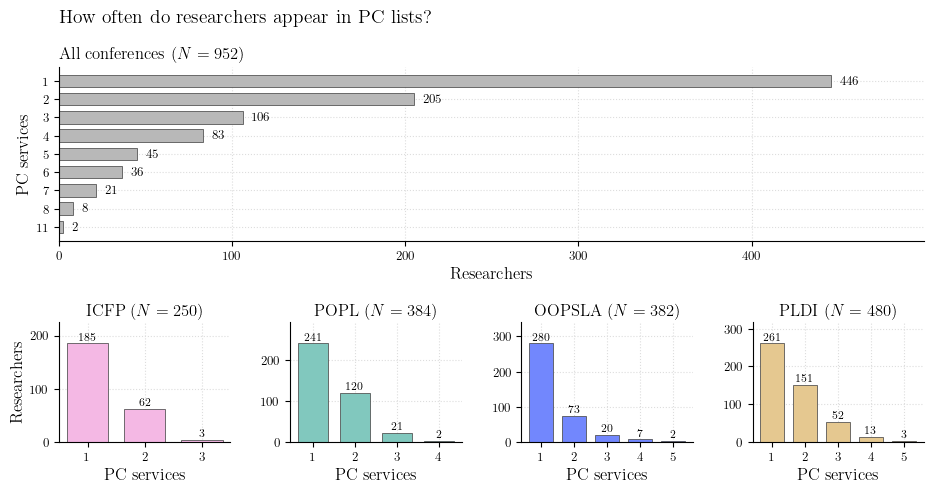

saved step_1_artifacts/figures/pc_service_distribution.pdf
saved step_1_artifacts/figures/pc_service_distribution.png


In [11]:
def clean_axis(ax):
    ax.grid(color=GRID, linestyle=":", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def annotate_horizontal(ax, values):
    max_value = max(values) if len(values) else 1
    for y, x in enumerate(values):
        if x > 0:
            ax.text(x + max_value * 0.012, y, str(int(x)), va="center", fontsize=9)


fig = plt.figure(figsize=(9.5, 5.0))
gs = fig.add_gridspec(
    2, 4,
    height_ratios=[1.45, 1],
    hspace=0.55,
    wspace=0.35,
    left=0.075,
    right=0.985,
    top=0.86,
    bottom=0.11,
)

ax_top = fig.add_subplot(gs[0, :])
levels = service_distribution["n_pc_services"].to_numpy()
values = service_distribution["researchers"].to_numpy()

ax_top.barh(
    np.arange(len(levels)),
    values,
    color=GREY,
    edgecolor=EDGE,
    linewidth=0.55,
    height=0.68,
)
annotate_horizontal(ax_top, values)
ax_top.set_yticks(np.arange(len(levels)))
ax_top.set_yticklabels(levels)
ax_top.invert_yaxis()
ax_top.set_xlabel("Researchers")
ax_top.set_ylabel("PC services")
ax_top.set_title(rf"All conferences ($N = {total_researchers}$)", loc="left", pad=6)
ax_top.set_xlim(0, values.max() * 1.12)
clean_axis(ax_top)

for i, conf in enumerate(CONFERENCES):
    ax = fig.add_subplot(gs[1, i])
    sub = service_distribution_by_conference.query("conference == @conf")
    levels_c = sub["n_pc_services"].to_numpy()
    values_c = sub["researchers"].to_numpy()
    ax.bar(
        levels_c,
        values_c,
        color=COLORS[conf],
        edgecolor=EDGE,
        linewidth=0.55,
        width=0.72,
    )
    for x, y in zip(levels_c, values_c):
        if y > 0:
            ax.text(x, y + max(values_c) * 0.035, str(int(y)), ha="center", fontsize=8)
    n_conf = int(service_by_conference.query("conference == @conf")["researcher_id"].nunique())
    ax.set_title(rf"{conf} ($N = {n_conf}$)", pad=5)
    ax.set_xlabel("PC services")
    if i == 0:
        ax.set_ylabel("Researchers")
    else:
        ax.set_ylabel("")
    ax.set_xticks(np.arange(1, int(levels_c.max()) + 1))
    ax.set_ylim(0, max(values_c) * 1.22)
    clean_axis(ax)

fig.suptitle(
    "How often do researchers appear in PC lists?",
    fontsize=14,
    x=0.075,
    y=0.975,
    ha="left",
)

pdf_out = images_dir / "pc_service_distribution.pdf"
png_out = images_dir / "pc_service_distribution.png"

fig.savefig(pdf_out, bbox_inches="tight", pad_inches=0.03)
fig.savefig(png_out, bbox_inches="tight", pad_inches=0.03, dpi=220)
plt.show()

print("saved", pdf_out.relative_to(repo))
print("saved", png_out.relative_to(repo))


The service count plot shows repeated PC service, but it does not by itself
distinguish between repeated service in the same conference and service across
different conferences. The next plot makes the cross conference overlap explicit.


## 5 - Conference Overlap

In [12]:
conference_overlap = (
    service_by_researcher["n_conferences"]
    .value_counts()
    .rename_axis("n_conferences")
    .reset_index(name="researchers")
    .sort_values("n_conferences")
)

membership = (
    pc
    .groupby("researcher_id")["conference"]
    .apply(lambda x: tuple(c for c in CONFERENCES if c in set(x.astype(str))))
)

combination_counts = (
    membership
    .value_counts()
    .rename_axis("combination_tuple")
    .reset_index(name="researchers")
)
combination_counts["combination"] = combination_counts["combination_tuple"].apply(
    lambda x: "All 4 conferences" if len(x) == len(CONFERENCES) else " + ".join(x)
)
combination_counts["n_conferences"] = combination_counts["combination_tuple"].apply(len)
combination_counts = combination_counts[
    ["combination", "n_conferences", "researchers"]
].sort_values(["researchers", "n_conferences", "combination"], ascending=[False, True, True])

conference_overlap.to_csv(summary_tables_dir / "pc_conference_overlap_counts.csv", index=False)
combination_counts.to_csv(summary_tables_dir / "pc_conference_combination_counts.csv", index=False)

display(conference_overlap)
display(combination_counts)


,n_conferences,researchers
0,1,578
1,2,238
2,3,102
3,4,34


,combination,n_conferences,researchers
0,PLDI,1,215
1,OOPSLA,1,146
2,POPL,1,117
3,ICFP,1,100
4,OOPSLA + PLDI,2,83
5,POPL + OOPSLA + PLDI,3,68
6,ICFP + POPL,2,62
7,POPL + PLDI,2,52
8,All 4 conferences,4,34
9,POPL + OOPSLA,2,21


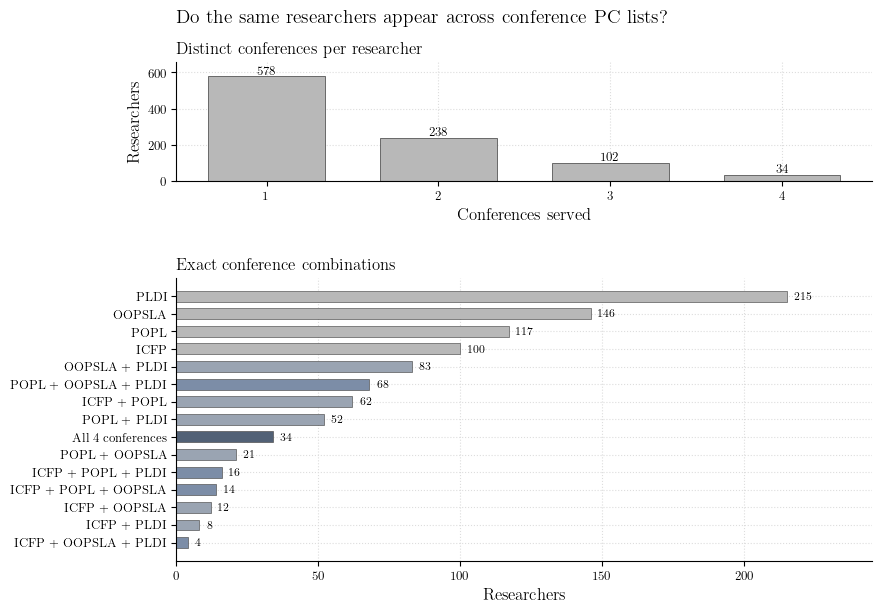

saved step_1_artifacts/figures/pc_members_across_conferences.pdf
saved step_1_artifacts/figures/pc_members_across_conferences.png


In [13]:
fig = plt.figure(figsize=(9.4, 6.2))
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[0.78, 1.85],
    hspace=0.48,
    left=0.245,
    right=0.985,
    top=0.90,
    bottom=0.095,
)

ax_top = fig.add_subplot(gs[0, 0])
x = conference_overlap["n_conferences"].to_numpy()
y = conference_overlap["researchers"].to_numpy()
ax_top.bar(
    x,
    y,
    color=GREY,
    edgecolor=EDGE,
    linewidth=0.55,
    width=0.68,
)
for x_i, y_i in zip(x, y):
    ax_top.text(x_i, y_i + max(y) * 0.025, str(int(y_i)), ha="center", fontsize=9)
ax_top.set_xticks(x)
ax_top.set_xlabel("Conferences served")
ax_top.set_ylabel("Researchers")
ax_top.set_title("Distinct conferences per researcher", loc="left", pad=6)
ax_top.set_ylim(0, max(y) * 1.14)
clean_axis(ax_top)

ax_bottom = fig.add_subplot(gs[1, 0])
combo = combination_counts.sort_values("researchers", ascending=True)
labels = combo["combination"].to_list()
values = combo["researchers"].to_numpy()
colors = [
    GREY if n == 1 else "#9aa4b2" if n == 2 else "#7c8da7" if n == 3 else "#526176"
    for n in combo["n_conferences"]
]

ax_bottom.barh(
    np.arange(len(combo)),
    values,
    color=colors,
    edgecolor=EDGE,
    linewidth=0.45,
    height=0.62,
)
max_value = values.max()
for y_i, x_i in enumerate(values):
    ax_bottom.text(x_i + max_value * 0.012, y_i, str(int(x_i)), va="center", fontsize=8)
ax_bottom.set_yticks(np.arange(len(combo)))
ax_bottom.set_yticklabels(labels)
ax_bottom.set_xlabel("Researchers")
ax_bottom.set_title("Exact conference combinations", loc="left", pad=6)
ax_bottom.set_xlim(0, max_value * 1.14)
clean_axis(ax_bottom)

fig.suptitle(
    "Do the same researchers appear across conference PC lists?",
    fontsize=14,
    x=0.245,
    y=0.985,
    ha="left",
)

pdf_out = images_dir / "pc_members_across_conferences.pdf"
png_out = images_dir / "pc_members_across_conferences.png"

fig.savefig(pdf_out, bbox_inches="tight", pad_inches=0.03)
fig.savefig(png_out, bbox_inches="tight", pad_inches=0.03, dpi=220)
plt.show()

print("saved", pdf_out.relative_to(repo))
print("saved", png_out.relative_to(repo))


## 6 - Short Stats

In [14]:
print(
    f"{repeat_researchers} of {total_researchers} researchers "
    f"({repeat_share:.1%}) appear in at least two visible PC service cells."
)
print(
    f"{multi_conf_researchers} of {total_researchers} researchers "
    f"({multi_conf_share:.1%}) appear in PC lists for at least two conferences."
)


506 of 952 researchers (53.2%) appear in at least two visible PC service cells.
374 of 952 researchers (39.3%) appear in PC lists for at least two conferences.
